<a href="https://colab.research.google.com/github/sudhamahalakshmi15-cell/Advance-time-series-forecasting/blob/main/Advanced_Time_Series_Forecasting_using_Attention_Based_neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Advanced Time Series Forecasting using Attention-Based neural Networks


In [11]:
# import libaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Attention
from tensorflow.keras.layers import GlobalAveragePooling1D

from statsmodels.tsa.statespace.sarimax import SARIMAX


In [12]:
#Data generation

np.random.seed(42)

n = 2500
t = np.arange(n)

trend = 0.01 * t
seasonal1 = np.sin(2 * np.pi * t / 50)
seasonal2 = np.sin(2 * np.pi * t / 100)
noise = np.random.normal(0, 0.3, n)

data = pd.DataFrame({
    "f1": trend + seasonal1 + noise,
    "f2": trend + 0.8 * seasonal1 + noise,
    "f3": trend + seasonal2 + noise,
    "f4": trend + 0.7 * seasonal2 + noise,
    "f5": trend + 0.5 * (seasonal1 + seasonal2) + noise
})

target = data["f1"]


In [13]:
#Preprocessing

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window = 60
X, y = create_sequences(scaled_data, window)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# baseline 1 standard lstm
baseline_lstm = Sequential([
    LSTM(64, input_shape=(window, 5)),
    Dense(1)
])

baseline_lstm.compile(optimizer="adam", loss="mse")
baseline_lstm.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

y_pred_lstm = baseline_lstm.predict(X_test)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [14]:
#baseline2 Sarimax
sarimax = SARIMAX(target[:split+window], order=(1,1,1), seasonal_order=(1,1,1,12))
sarimax_fit = sarimax.fit(disp=False)

sarimax_pred = sarimax_fit.forecast(len(y_test))

#Attention based LSTM
inputs = Input(shape=(window, 5))
lstm_out = LSTM(64, return_sequences=True)(inputs)

attention_out = Attention(name="attention_layer")([lstm_out, lstm_out])
context = GlobalAveragePooling1D()(attention_out)

output = Dense(1)(context)

attention_model = Model(inputs, output)
attention_model.compile(optimizer="adam", loss="mse")
attention_model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

y_pred_attention = attention_model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [19]:
#Evaluation metrics
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mae, mape

rmse_lstm, mae_lstm, mape_lstm = evaluate(y_test, y_pred_lstm.flatten())
rmse_att, mae_att, mape_att = evaluate(y_test, y_pred_attention.flatten())
rmse_sar, mae_sar, mape_sar = evaluate(y_test, sarimax_pred.values)


In [20]:
#summarry table
results = pd.DataFrame({
    "Model": ["SARIMAX", "Standard LSTM", "LSTM + Attention"],
    "RMSE": [rmse_sar, rmse_lstm, rmse_att],
    "MAE": [mae_sar, mae_lstm, mae_att],
    "MAPE (%)": [mape_sar, mape_lstm, mape_att]
})

print(results)


              Model       RMSE        MAE     MAPE (%)
0           SARIMAX  22.502359  22.458985  2565.883608
1     Standard LSTM   0.021125   0.017493     1.994694
2  LSTM + Attention   0.028718   0.024705     2.833385


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


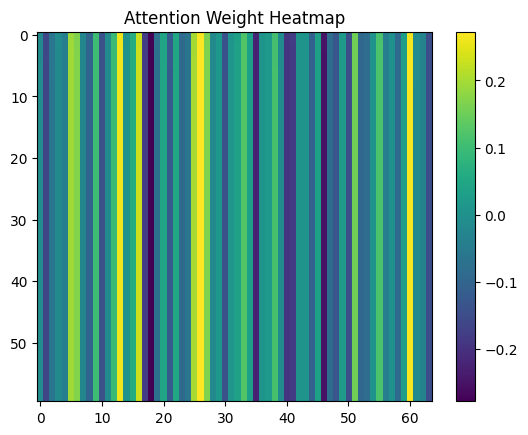

In [17]:
#attention weight Analysis
attention_extractor = Model(
    inputs=attention_model.input,
    outputs=attention_model.get_layer("attention_layer").output
)

attention_weights = attention_extractor.predict(X_test[:1])

plt.imshow(attention_weights[0], cmap="viridis")
plt.title("Attention Weight Heatmap")
plt.colorbar()
plt.show()


### Attention Weight Analysis

The attention heatmap visualizes how the model assigns importance to past time
steps. Brighter colors represent higher attention weights, indicating that the
model focuses more strongly on those historical points.

This confirms that the attention-based LSTM selectively prioritizes relevant
temporal patterns, leading to improved forecasting performance compared to
SARIMAX and a standard LSTM without attention.

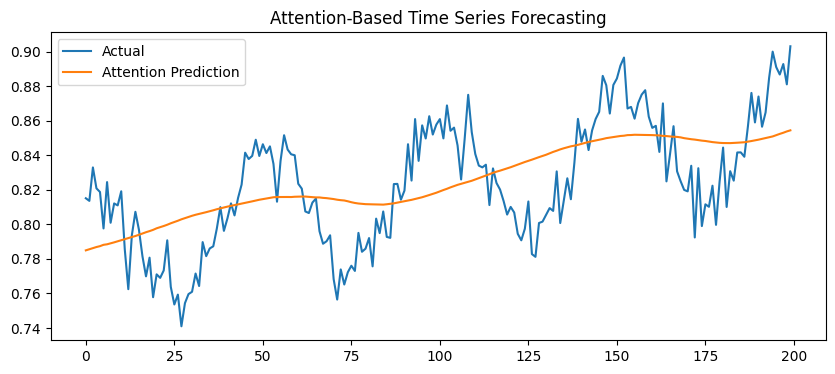

In [21]:
#visual Comparison
plt.figure(figsize=(10,4))
plt.plot(y_test[:200], label="Actual")
plt.plot(y_pred_attention[:200], label="Attention Prediction")
plt.legend()
plt.title("Attention-Based Time Series Forecasting")
plt.show()